In [1]:
import pandas as pd
df = pd.read_csv("/Users/ENPC/cours 3/3 MCNDU/projet/MCNDU_final_dataset.csv",sep=';')  
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2552456 entries, 0 to 2552455
Data columns (total 25 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   Occupation                 float64
 1   Debit                      float64
 2   Arc Name                   object 
 3   Arc ID                     int64  
 4   Datetime                   object 
 5   End Date Available Data    object 
 6   Start Date Available Data  object 
 7   ID Upstream Node           int64  
 8   Trafic                     object 
 9   ID Downstream Node         int64  
 10  Upstream Node Name         object 
 11  Arc State                  float64
 12  Downstream Node Name       object 
 13  Latitude                   float64
 14  Longitude                  float64
 15  Arrondissement             float64
 16  near_ZTL                   int64  
 17  in_ZTL                     int64  
 18  near_A1                    int64  
 19  near_A3                    int64  
 20  ne

In [3]:
df.head()

,Occupation,Debit,Arc Name,Arc ID,Datetime,End Date Available Data,Start Date Available Data,ID Upstream Node,Trafic,ID Downstream Node,...,Arrondissement,near_ZTL,in_ZTL,near_A1,near_A3,near_A4,near_A6a,near_A6b,near_A13,ZTL_enforced
0,6.77778,569.0,Bd_Malesherbes,239,2026-01-05 15:00:00+00:00,2023-01-01,1996-10-03,144,Fluide,146,...,8.0,1,0,0,0,0,0,0,0,True
1,2.77555,153.0,Bd_Jourdan,726,2026-01-05 15:00:00+00:00,2023-01-01,1996-10-03,416,Fluide,422,...,14.0,0,0,0,0,0,1,0,0,True
2,16.82722,1133.0,Royale,242,2026-01-05 15:00:00+00:00,2023-01-01,1996-10-03,147,Pré-saturé,149,...,8.0,1,0,0,0,0,0,0,0,True
3,10.26000,525.0,Concorde_Nord,236,2026-01-05 15:00:00+00:00,2023-01-01,1996-10-03,142,Fluide,140,...,8.0,1,0,0,0,0,0,0,0,True
4,6.55723,597.0,Concorde,230,2026-01-05 15:00:00+00:00,2023-01-01,1996-10-03,134,Fluide,137,...,8.0,1,0,0,0,0,0,0,0,True


In [5]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['hour'] = df['Datetime'].dt.hour
df['date'] = df['Datetime'].dt.date
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2552456 entries, 0 to 2552455
Data columns (total 27 columns):
 #   Column                     Dtype              
---  ------                     -----              
 0   Occupation                 float64            
 1   Debit                      float64            
 2   Arc Name                   object             
 3   Arc ID                     int64              
 4   Datetime                   datetime64[ns, UTC]
 5   End Date Available Data    object             
 6   Start Date Available Data  object             
 7   ID Upstream Node           int64              
 8   Trafic                     object             
 9   ID Downstream Node         int64              
 10  Upstream Node Name         object             
 11  Arc State                  float64            
 12  Downstream Node Name       object             
 13  Latitude                   float64            
 14  Longitude                  float64            
 15

# Debit et taux d'occupation moyen horaire avant et pendent la mise en place de la ZTL

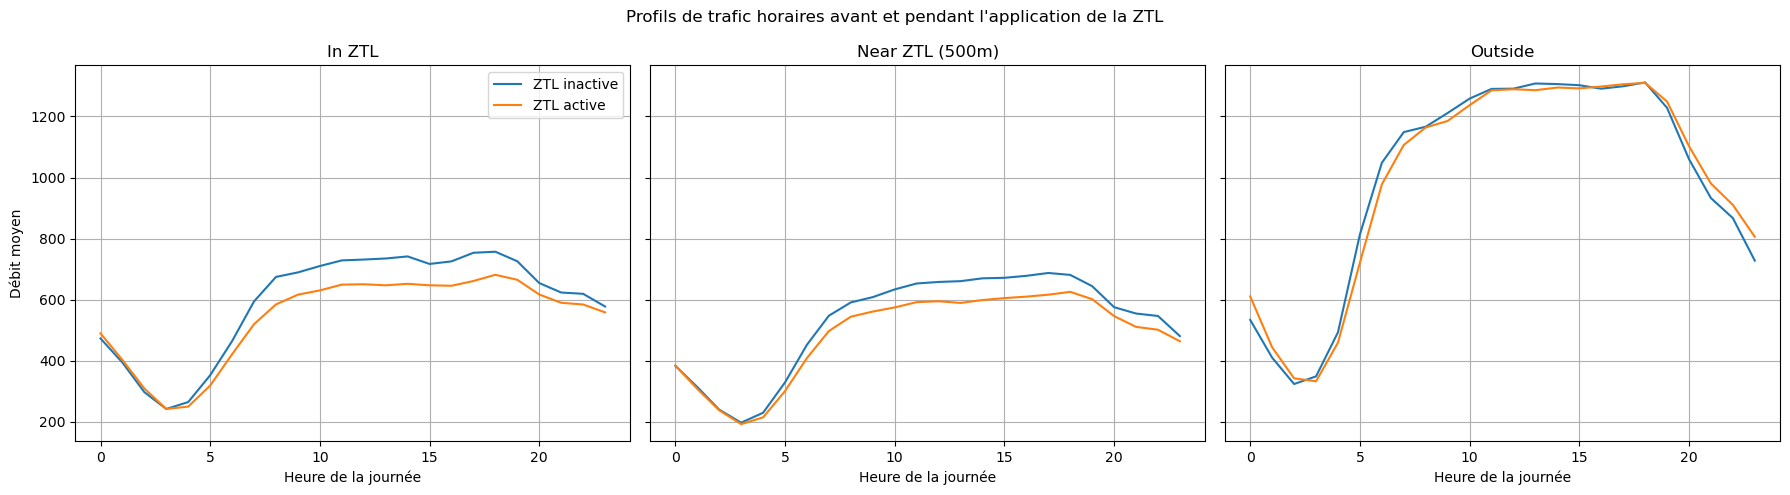

In [8]:
import matplotlib.pyplot as plt

def spatial_group(row):
    if row['in_ZTL'] == 1:
        return 'In ZTL'
    elif row['near_ZTL'] == 1:
        return 'Near ZTL (500m)'
    else:
        return 'Outside'

df['group'] = df.apply(spatial_group, axis=1)

# group × hour × ZTL_enforced
hourly_mean = (
    df.groupby(['group', 'hour', 'ZTL_enforced'])['Debit'].mean().reset_index())
groups = ['In ZTL', 'Near ZTL (500m)', 'Outside']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, g in zip(axes, groups):
    sub = hourly_mean[hourly_mean['group'] == g]
    for status, label in [(False, 'ZTL inactive'),(True, 'ZTL active')]:
        tmp = sub[sub['ZTL_enforced'] == status]
        ax.plot(tmp['hour'], tmp['Debit'], label=label)
    ax.set_title(g)
    ax.set_xlabel('Heure de la journée')
    ax.grid(True)

axes[0].set_ylabel('Débit moyen')
axes[0].legend()

plt.suptitle("Profils de trafic horaires avant et pendant l'application de la ZTL")
plt.tight_layout()
plt.show()

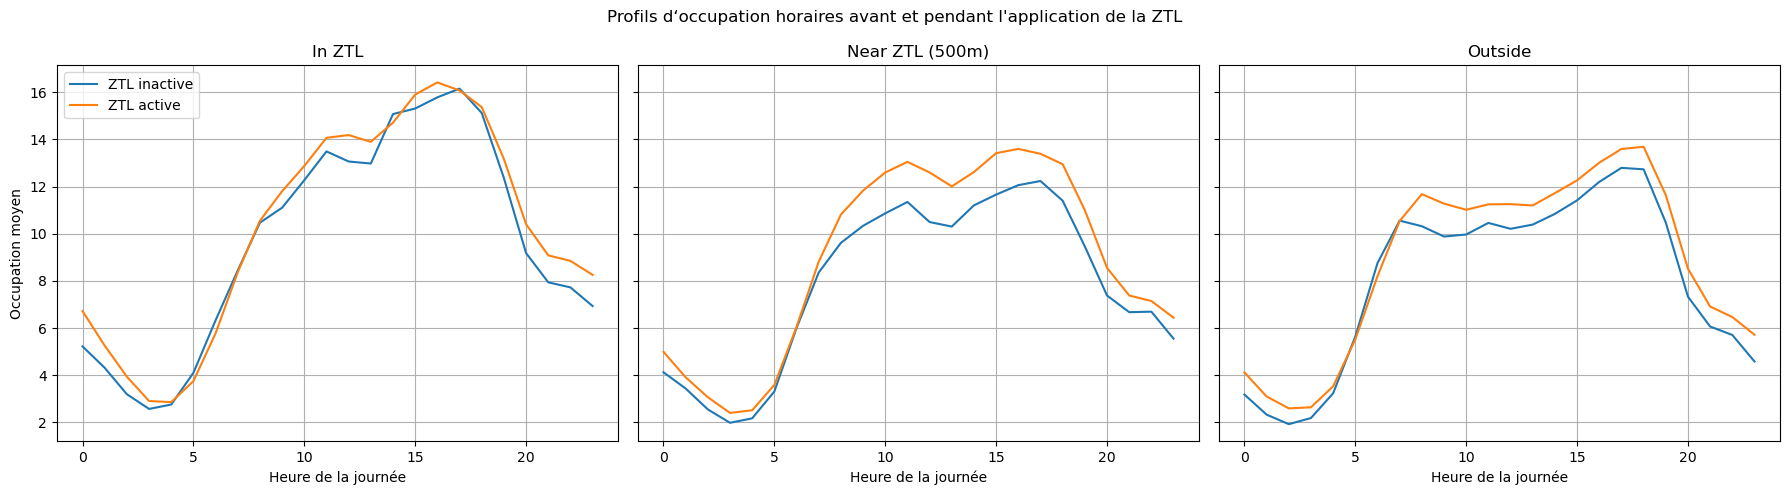

In [10]:
hourly_mean_occu = (
    df.groupby(['group', 'hour', 'ZTL_enforced'])['Occupation'].mean().reset_index())
groups = ['In ZTL', 'Near ZTL (500m)', 'Outside']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, g in zip(axes, groups):
    sub = hourly_mean_occu[hourly_mean_occu['group'] == g]

    for status, label in [(False, 'ZTL inactive'),(True, 'ZTL active')]:
        tmp = sub[sub['ZTL_enforced'] == status]
        ax.plot(tmp['hour'], tmp['Occupation'], label=label)

    ax.set_title(g)
    ax.set_xlabel('Heure de la journée')
    ax.grid(True)

axes[0].set_ylabel('Occupation moyen')
axes[0].legend()

plt.suptitle("Profils d‘occupation horaires avant et pendant l'application de la ZTL")
plt.tight_layout()
plt.show()

# variation moyenne due à l'application de la ZTL

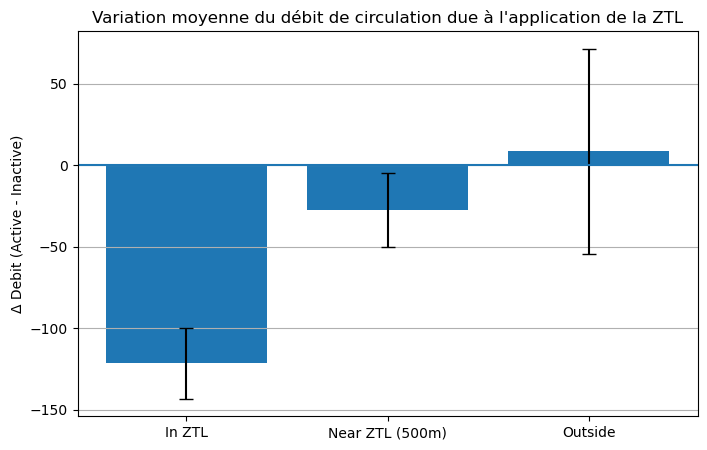

In [13]:
# valeur moyenne de after-before pour chaque arc
point_avg = (df.groupby(['Arc ID', 'group', 'ZTL_enforced'])['Debit'].mean().unstack().reset_index())
point_avg['delta_flow'] = point_avg[True] - point_avg[False]

# Agrégation pour chaque groupe
delta_group = (point_avg.groupby('group')['delta_flow'].agg(['mean', 'std', 'count']).reset_index())
delta_group['se'] = delta_group['std'] / delta_group['count']**0.5

plt.figure(figsize=(8, 5))
plt.bar(delta_group['group'], delta_group['mean'],yerr=1.96 * delta_group['se'], capsize=5)
plt.axhline(0)
plt.ylabel('Δ Debit (Active - Inactive)')
plt.title("Variation moyenne du débit de circulation due à l'application de la ZTL")
plt.grid(axis='y')
plt.show()

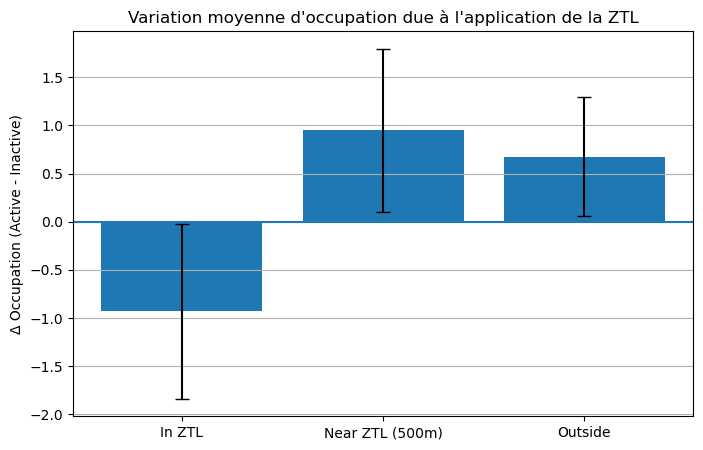

In [15]:
# valeur moyenne de after-before pour chaque arc
point_avg = (df.groupby(['Arc ID', 'group', 'ZTL_enforced'])['Occupation'].mean().unstack().reset_index())
point_avg['delta_Occupation'] = point_avg[True] - point_avg[False]

# Agrégation pour chaque groupe
delta_group = (point_avg.groupby('group')['delta_Occupation'].agg(['mean', 'std', 'count']).reset_index())
delta_group['se'] = delta_group['std'] / delta_group['count']**0.5

plt.figure(figsize=(8, 5))
plt.bar(delta_group['group'], delta_group['mean'],yerr=1.96 * delta_group['se'], capsize=5)
plt.axhline(0)
plt.ylabel('Δ Occupation (Active - Inactive)')
plt.title("Variation moyenne d'occupation due à l'application de la ZTL")
plt.grid(axis='y')
plt.show()

# variations quotidiennes par période

In [18]:
def period(hour):
    if 7 <= hour <= 10:
        return 'Morning peak'
    elif 16 <= hour <= 19:
        return 'Evening peak'
    else:
        return 'Off-peak'

df['period'] = df['hour'].apply(period)

/var/folders/yd/68c6wh4n59z5mt268g975jd40000gn/T/ipykernel_99017/2793394086.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  peak_avg = (df.groupby(['group', 'period', 'ZTL_enforced'])['Debit'].mean().reset_index())


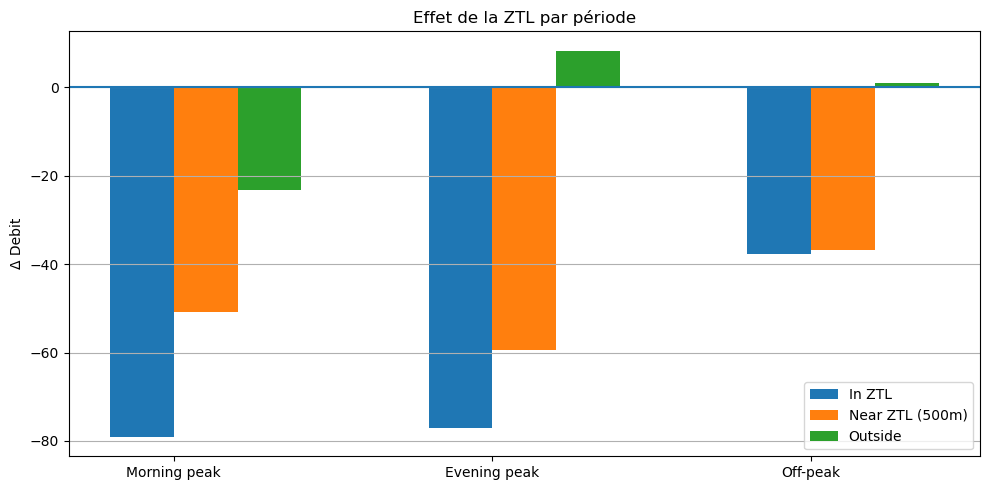

In [20]:
import numpy as np
period_order = ['Morning peak', 'Evening peak', 'Off-peak']
df['period'] = pd.Categorical(df['period'],categories=period_order,ordered=True)

peak_avg = (df.groupby(['group', 'period', 'ZTL_enforced'])['Debit'].mean().reset_index())
delta_df = []
for g in ['In ZTL', 'Near ZTL (500m)','Outside']:
    sub = peak_avg[peak_avg['group'] == g]
    delta = (sub[sub['ZTL_enforced'] == True].set_index('period')['Debit']-sub[sub['ZTL_enforced'] == False].set_index('period')['Debit'])
    tmp = delta.reset_index()
    tmp['group'] = g
    delta_df.append(tmp)
delta_df = pd.concat(delta_df)

x = np.arange(len(period_order))
width = 0.2
plt.figure(figsize=(10, 5))
for i, g in enumerate(['In ZTL', 'Near ZTL (500m)','Outside']):
    vals = (delta_df[delta_df['group'] == g].set_index('period').loc[period_order, 'Debit'])
    plt.bar(x + i * width,vals.values,width=width,label=g)
plt.axhline(0)
plt.xticks(x + width / 2, period_order)
plt.ylabel('Δ Debit')
plt.title('Effet de la ZTL par période')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

/var/folders/yd/68c6wh4n59z5mt268g975jd40000gn/T/ipykernel_99017/965674507.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['group', 'period', 'ZTL_enforced'])['Occupation'].mean().reset_index())


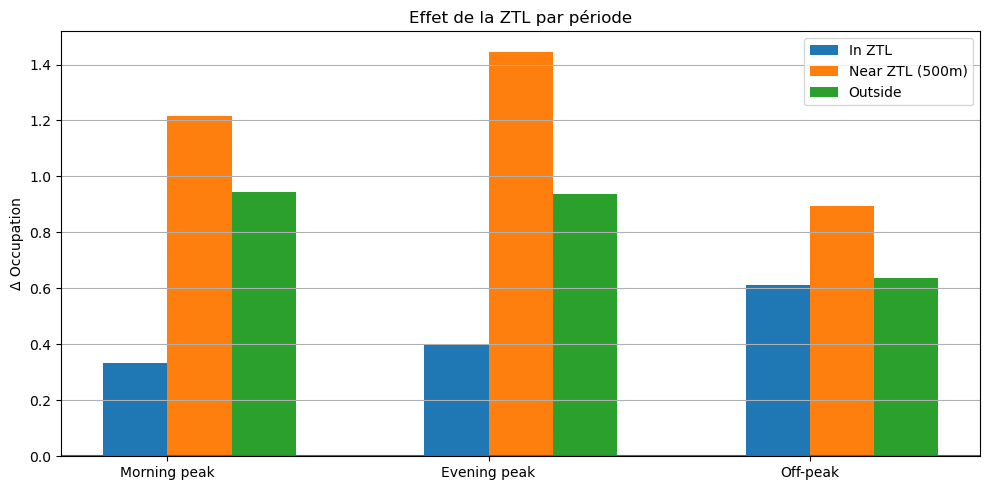

In [22]:
peak_avg = (
    df.groupby(['group', 'period', 'ZTL_enforced'])['Occupation'].mean().reset_index())
delta_df = []
for g in ['In ZTL', 'Near ZTL (500m)','Outside']:
    sub = peak_avg[peak_avg['group'] == g]
    delta = (sub[sub['ZTL_enforced'] == True].set_index('period')['Occupation']-sub[sub['ZTL_enforced'] == False].set_index('period')['Occupation'])
    tmp = delta.reset_index()
    tmp['group'] = g
    delta_df.append(tmp)
delta_df = pd.concat(delta_df)

x = np.arange(len(period_order))
width = 0.2
plt.figure(figsize=(10, 5))
for i, g in enumerate(['In ZTL', 'Near ZTL (500m)','Outside']):
    vals = (delta_df[delta_df['group'] == g].set_index('period').loc[period_order, 'Occupation'])
    plt.bar(x + i * width,vals.values,width=width,label=g)
plt.axhline(0)
plt.xticks(x + width / 2, period_order)
plt.ylabel('Δ Occupation')
plt.title('Effet de la ZTL par période')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()